In [15]:
#import tensorflow as tf

In [16]:
import math
import numpy as np
import matplotlib.pyplot as plt #for visualization
from sympy import symbols, Eq, solve
from scipy.integrate import solve_ivp

In [17]:
print("hello")

hello


In [18]:
#set up compartmental model
S = symbols('S')
E = symbols('E')
I = symbols('I')
R  = symbols('R')
beta = symbols('beta')
gamma = symbols('gamma')
alpha = symbols('alpha')
Lambda = symbols('Lambda')
mu = symbols('mu')

#estimated strep parameters
#gamma = 1
#alpha = 1

dS = Lambda - beta*S*I - mu*S
dE = beta*S*I - alpha*E - mu*E
dI = alpha*E - gamma*I - mu*I
dR = gamma*I - mu*R

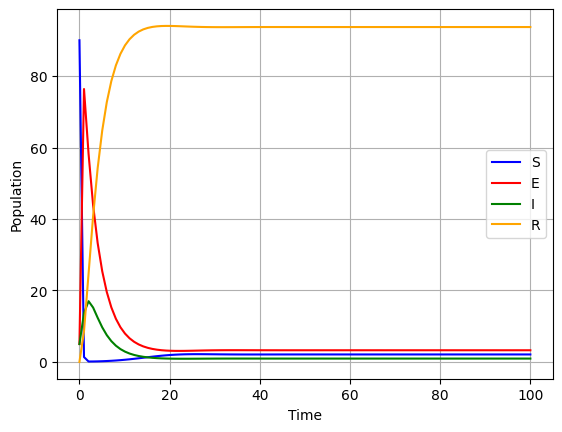

In [19]:
gamma = 1
alpha = 0.29
beta = 0.5
mu = 0.01
Lambda = 1

#from literature: r0 = 2.2 giving beta=0.22


def model(t, state):
    S,E,I,R = state
    dSdt = Lambda - beta*S*I - mu*S
    dEdt = beta*S*I - alpha*E - mu*E
    dIdt = alpha*E - gamma*I - mu*I
    dRdt = gamma*I - mu*R
    return [dSdt,dEdt,dIdt,dRdt]

t_span = (0, 100)
initial = (90, 5, 5, 0)

t_evaluate = np.linspace(0, 100, 100)

sol = solve_ivp(fun = model, t_span = t_span, y0 = initial, method = 'RK45', t_eval = t_evaluate)


plt.plot(sol.t, sol.y[0], label='S', color='blue')
plt.plot(sol.t, sol.y[1], label='E', color='red')
plt.plot(sol.t, sol.y[2], label='I', color='green')
plt.plot(sol.t, sol.y[3], label='R', color='orange')
plt.xlabel('Time')
plt.ylabel('Population')
plt.legend()
plt.grid(True)
plt.show()

Text(0, 0.5, 'Proportion')

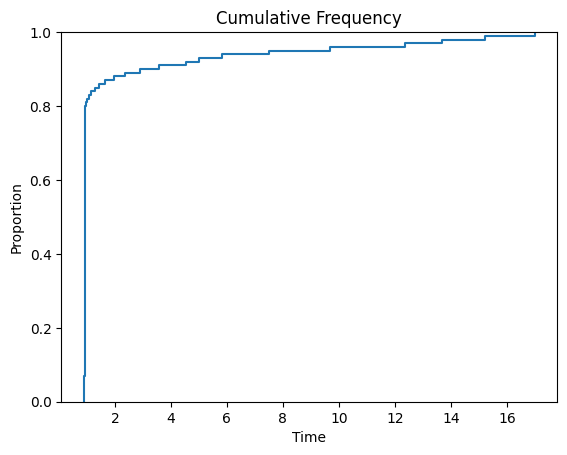

In [20]:
data = sol.y[2]
fig, ax = plt.subplots()

# Plot the exact cumulative curve
ax.ecdf(data, label="Cumulative Incidence")

ax.set_title("Cumulative Frequency")
ax.set_xlabel("Time")
ax.set_ylabel("Proportion")

7.0710678118654755
finished iterations


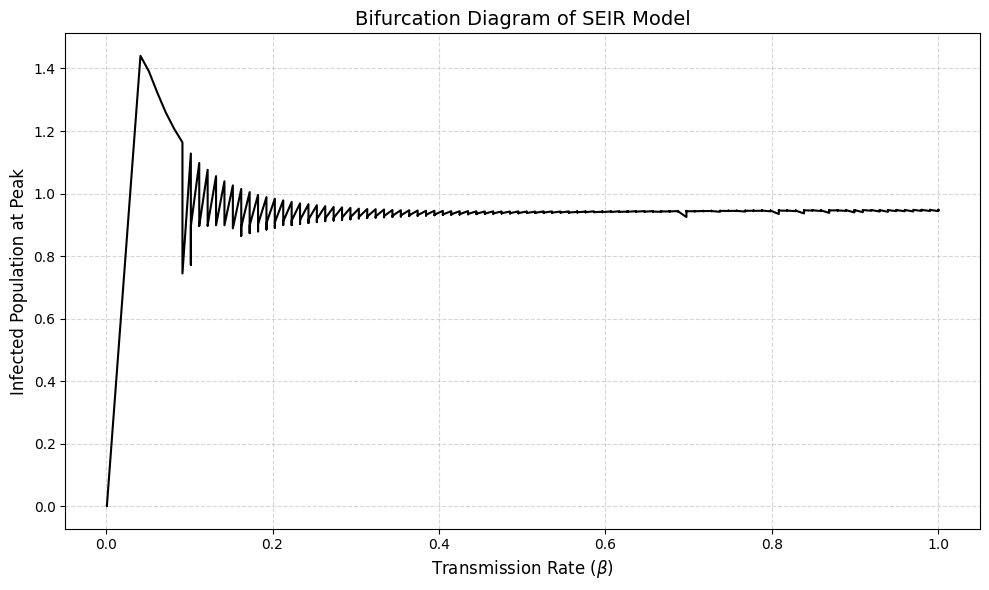

In [21]:
#bifurcation diagram for I* vs R0

#R0 = math.sqrt((alpha*beta*Lambda)/(mu*(mu+alpha)*(mu*gamma)))
R0 = math.sqrt(Lambda/mu)*math.sqrt(beta/gamma) #here we assume a steady population where deaths and immigration over a three-week interval are negligible
print(R0)

beta_min = 0.001
beta_max = 1

beta_evaluate = np.linspace(beta_min, beta_max, 100)
transient_time = 14 #model peaks quickly

bifurcation_beta = []
bifurcation_I = []

for val in range(len(beta_evaluate)):
    beta = beta_evaluate[val]
    sol = solve_ivp(fun = model, t_span = t_span, y0 = initial, method = 'RK45', t_eval = t_evaluate)

    I_pop = sol.y[2]
    
    # Isolate the attractor (discard the transient burn-in period)
    # We take the local peaks to build a clear bifurcation diagram
    I_steady = I_pop[transient_time :]
    
    peaks = []
    for i in range(1, len(I_steady) - 1):
        if I_steady[i] > I_steady[i-1] and I_steady[i] > I_steady[i+1]:
            peaks.append(I_steady[i])
            
    # Store points for plotting
    for peak in peaks:
        bifurcation_beta.append(beta)
        bifurcation_I.append(peak)


print("finished iterations")
plt.figure(figsize=(10, 6))
plt.plot(bifurcation_beta, bifurcation_I, color='black') #, alpha=0.5)

plt.title('Bifurcation Diagram of SEIR Model', fontsize=14)
plt.xlabel('Transmission Rate ($\\beta$)', fontsize=12)
plt.ylabel('Infected Population at Peak', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
